# Fetch solar radiation (Open-Meteo ERA5) and add it to the weather CSV

A standalone ETL step that:
1. Pulls **hourly global horizontal irradiance** (`shortwave_radiation`, W/m²) for Cork, 2021–2025, from the free Open-Meteo ERA5 archive.
2. **Validates** that the fetched timestamps line up with your existing weather CSV (by comparing temperatures).
3. Writes a **new CSV** with an extra `solar` column.

This keeps `weather_loading.py` independent of any network/API code — the model just reads one more column later.

**Data note for the thesis:** Open-Meteo's historical archive is ERA5 reanalysis at ~25 km resolution (modelled, gap-free, CC BY 4.0). Cite it as reanalysis, not a station reading.

## Requirements
```
pip install requests pandas matplotlib
```
You need internet access to reach `archive-api.open-meteo.com`. The free tier is fine — this fetches one point, one variable, five years (5 small requests).

In [1]:
import time
import requests
import pandas as pd

## Configuration — edit these, then *Run All*

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================
# Location. Default is Cork Airport (the Met Éireann synoptic station). Set this
# to match the station your existing temp/humidity CSV came from, so the solar
# data is drawn from the same area.
LATITUDE  = 51.8413     # Cork Airport
LONGITUDE = -8.4911

# Period to fetch (inclusive), matching your weather CSV span.
START_YEAR = 2021
END_YEAR   = 2025

# Timezone of the TIMESTAMPS.
#   Met Eireann hourly data is in UTC, and Open-Meteo returns UTC when timezone
#   is "GMT" -- so the two align directly. If your CSV 'time' column is in Irish
#   LOCAL time instead, set this to "Europe/Dublin".
TIMEZONE = "GMT"

# shortwave_radiation (W/m2) is the variable we keep. temperature_2m and
# relative_humidity_2m are fetched ONLY to check the timestamps line up with
# your CSV; they are not merged in.
SOLAR_VAR       = "shortwave_radiation"
VALIDATION_VARS = ["temperature_2m", "relative_humidity_2m"]

# Files (relative to this notebook).
INPUT_CSV  = "../data/processed/cork_weather_hourly_model_input_2021_2025.csv"
OUTPUT_CSV = "../data/processed/cork_weather_hourly_model_input_2021_2025_with_solar.csv"

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"


## Fetch

One request per year (resilient and easy to inspect), with a couple of retries and a polite pause between calls.

In [3]:
def fetch_year(year, variables, retries=3, pause=1.0):
    """Hourly `variables` for one calendar year from the Open-Meteo ERA5 archive.
       Returns a DataFrame indexed by (timezone-naive) timestamp."""
    params = {
        "latitude":  LATITUDE,
        "longitude": LONGITUDE,
        "start_date": f"{year}-01-01",
        "end_date":   f"{year}-12-31",
        "hourly":   ",".join(variables),
        "timezone": TIMEZONE,
    }
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            r = requests.get(ARCHIVE_URL, params=params, timeout=60)
            r.raise_for_status()
            hourly = r.json()["hourly"]
            df = pd.DataFrame(hourly)
            df["time"] = pd.to_datetime(df["time"])
            return df.set_index("time")
        except Exception as e:
            last_err = e
            print(f"  {year}: attempt {attempt} failed ({e}); retrying...")
            time.sleep(pause * attempt)
    raise RuntimeError(f"failed to fetch {year}: {last_err}")

In [4]:
variables = [SOLAR_VAR] + VALIDATION_VARS
frames = []
for yr in range(START_YEAR, END_YEAR + 1):
    print(f"fetching {yr} ...")
    frames.append(fetch_year(yr, variables))
    time.sleep(1.0)                       # be polite to the free API

solar_df = pd.concat(frames).sort_index()
solar_df = solar_df[~solar_df.index.duplicated(keep="first")]
print(f"done: {len(solar_df)} hourly rows, "
      f"{solar_df.index.min()} -> {solar_df.index.max()}")
solar_df.head()

fetching 2021 ...
fetching 2022 ...
fetching 2023 ...
fetching 2024 ...
fetching 2025 ...
done: 43824 hourly rows, 2021-01-01 00:00:00 -> 2025-12-31 23:00:00


,shortwave_radiation,temperature_2m,relative_humidity_2m
time,,,
2021-01-01 00:00:00,0.0,3.7,83
2021-01-01 01:00:00,0.0,3.2,85
2021-01-01 02:00:00,0.0,3.0,85
2021-01-01 03:00:00,0.0,2.8,86
2021-01-01 04:00:00,0.0,2.7,88


## Validate the solar series

In [5]:
s = solar_df[SOLAR_VAR]
print(f"{SOLAR_VAR}: min {s.min():.0f}, mean {s.mean():.0f}, max {s.max():.0f} W/m2")
print("NaNs:", int(s.isna().sum()))
print("\nMonthly mean solar (W/m2) -- should peak in summer (Jun/Jul):")
print(s.groupby(solar_df.index.month).mean().round(0).to_dict())

shortwave_radiation: min 0, mean 121, max 895 W/m2
NaNs: 0

Monthly mean solar (W/m2) -- should peak in summer (Jun/Jul):
{1: 35.0, 2: 59.0, 3: 106.0, 4: 169.0, 5: 213.0, 6: 216.0, 7: 206.0, 8: 182.0, 9: 125.0, 10: 71.0, 11: 41.0, 12: 26.0}


## Check the timestamps line up with your CSV

The merge is only valid if Open-Meteo's clock matches your CSV's. We test that indirectly: fetch Open-Meteo's own temperature and compare it to your CSV's `temp` at matched timestamps. Tight agreement ⇒ aligned. A systematic ~1-hour offset (worse in summer) ⇒ the `TIMEZONE` setting is wrong (flip between `"GMT"` and `"Europe/Dublin"`).

In [6]:
wx_check = pd.read_csv(INPUT_CSV)
wx_check["time"] = pd.to_datetime(wx_check["time"])
chk = wx_check.set_index("time").join(solar_df[["temperature_2m"]], how="inner")

diff = chk["temp"] - chk["temperature_2m"]
print(f"matched rows : {len(chk)}")
print(f"temp diff (CSV - Open-Meteo): mean {diff.mean():+.2f} C, "
      f"mean|abs| {diff.abs().mean():.2f} C")
print(f"correlation  : {chk['temp'].corr(chk['temperature_2m']):.3f}")
print("\nAligned if mean|abs| is small (<= ~1.5 C) and corr > 0.95.")

matched rows : 43824
temp diff (CSV - Open-Meteo): mean +0.40 C, mean|abs| 1.07 C
correlation  : 0.966

Aligned if mean|abs| is small (<= ~1.5 C) and corr > 0.95.


## Merge solar into the CSV and save a new file

In [7]:
wx = pd.read_csv(INPUT_CSV)
wx["_ts"] = pd.to_datetime(wx["time"])

solar_col = solar_df[[SOLAR_VAR]].rename(columns={SOLAR_VAR: "solar"})
out = wx.set_index("_ts").join(solar_col, how="left").reset_index(drop=True)

missing = int(out["solar"].isna().sum())
if missing:
    print(f"WARNING: {missing} rows had no matching solar value -> filling 0. "
          f"If this number is large, re-check TIMEZONE and coordinates.")
    out["solar"] = out["solar"].fillna(0.0)

out["solar"] = out["solar"].round(1)
out.to_csv(OUTPUT_CSV, index=False)
print(f"saved {OUTPUT_CSV}")
print(f"  {len(out)} rows, columns: {list(out.columns)}")
out.head()

saved ../data/processed/cork_weather_hourly_model_input_2021_2025_with_solar.csv
  43824 rows, columns: ['time', 'year', 'month', 'day', 'temp', 'rhum', 'solar']


,time,year,month,day,temp,rhum,solar
0,2021-01-01 00:00:00,2021,1,1,4.8,81,0.0
1,2021-01-01 01:00:00,2021,1,1,4.9,78,0.0
2,2021-01-01 02:00:00,2021,1,1,4.8,80,0.0
3,2021-01-01 03:00:00,2021,1,1,4.7,80,0.0
4,2021-01-01 04:00:00,2021,1,1,4.4,82,0.0


## (Optional) Eyeball the diurnal shape

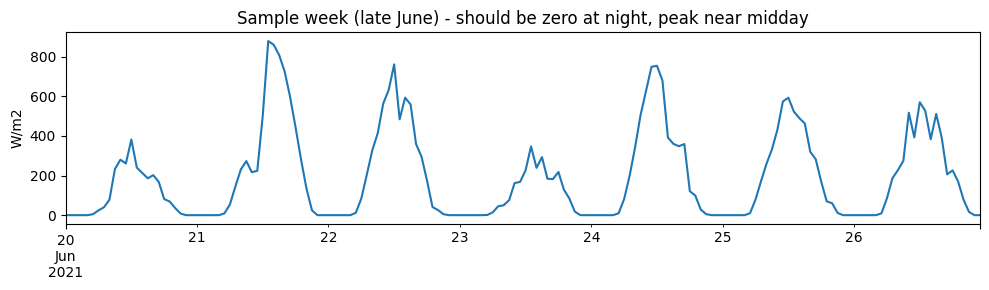

In [8]:
import matplotlib.pyplot as plt
sample = solar_df.loc[f"{START_YEAR}-06-20":f"{START_YEAR}-06-26", SOLAR_VAR]
ax = sample.plot(figsize=(10, 3),
                 title="Sample week (late June) - should be zero at night, peak near midday")
ax.set_ylabel("W/m2"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## Next step: let `weather_loading.py` read the new column

The fetch is done and the CSV now has `solar`. To actually *use* it, make two tiny additions to `load_weather_csv` / `WeatherSeries` in `weather_loading.py` (this is just reading a column — no API code enters the model):

```python
# near the other column-candidate lists
_SOLAR_COLS = ["solar", "shortwave_radiation", "ghi", "glorad", "radiation"]

# in load_weather_csv(...), alongside the temp/rh handling:
scol = _pick(cols, _SOLAR_COLS)
if scol is not None:
    out["solar"] = pd.to_numeric(raw[scol], errors="coerce")

# in WeatherSeries.at(...), pass it through:
solar = float(row["solar"]) if "solar" in self.df.columns and pd.notna(row.get("solar")) else 0.0
return WeatherConditions(air_temp_c=float(row["temp"]),
                         relative_humidity=rh, solar_W_m2=max(solar, 0.0))
```

Then point `WEATHER_CSV_PATH` at the new file (`...with_solar.csv`). The `solar_W_m2` term is already wired into `hvac_kW_thermal`, so cooling/heating loads will start responding to sunshine immediately — and it's the input you'll feed into the sol-air trigger we discussed.